In [1]:
import cv2
import os 
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 

In [3]:
from torchvision import datasets 
import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

PREPROCESSING 

In [4]:
#train 
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.Normalize((0.1307,), (0.3081,))
])

#test 
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

x_train = datasets.MNIST(root='data', train=True, download=True, transform=train_transform)
x_test = datasets.MNIST(root='data', train=False, download=True, transform=test_transform)


loaders={
    'train' : DataLoader(x_train, batch_size=100, shuffle=True,num_workers=1),
    'test' : DataLoader(x_test, batch_size=100, shuffle=True,num_workers=1)
}

print(f'Train dataset size: {len(x_train)}')
print(f'Test dataset size: {len(x_test)}')

Train dataset size: 60000
Test dataset size: 10000


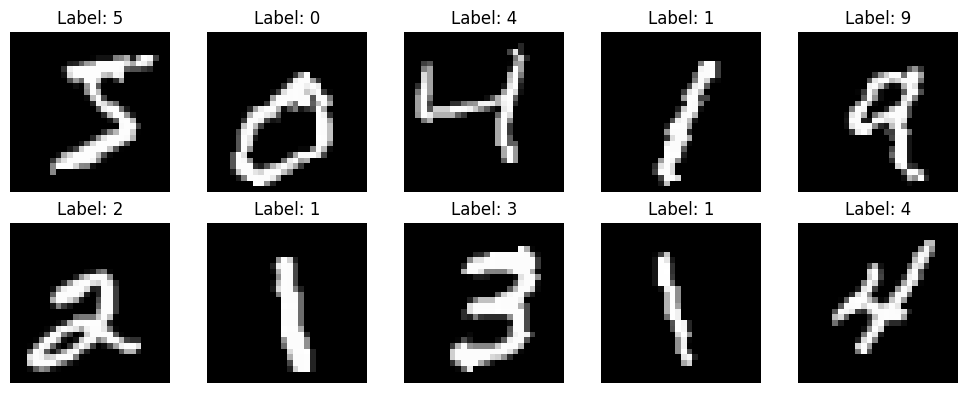

In [5]:
fig,axes =plt.subplots(2,5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
    img, label = x_train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.savefig("plots/sample_images.png", dpi=300, bbox_inches='tight')
plt.show()

MY CNN